# Study 3 — judge panels across budget regimes (appendix G.4.2)

Does a cheap, small-model-only judge panel, put through the same DIAL calibration as every
other real-data result, match human-only evaluation and a large or full panel? And how does
the answer move as either budget — human labels or LLM comparisons — becomes the scarce one?

Three sweeps, each drawn on the same 3 × 3 grid (datasets × judge panels) and in **two
metrics**: excess held-out log loss and Kendall's $\tau$ against the held-out human ranking.

| Figure | Sweep | Fixed |
|---|---|---|
| `fig_small_panel[_tau]` | human budget $n_H$ | as-collected LLM data |
| `fig_small_panel_llmbudget[_tau]` | LLM budget $n_L$ | $n_H = 300 / 80 / 60$ |
| `fig_intermediate_budget[_tau]` | human budget $n_H$ | $n_L = 2000 / 160 / 100$ |

The two metrics answer different questions and disagree in emphasis: log loss charges by the
probability gap and by how many test comparisons fall on a pair, so it is dominated by the
low-budget regime where the adaptive fit is unstable; $\tau$ charges every misordered pair
equally, which is the quantity a leaderboard actually reports.

Panels: `small6` (six open-weight judges, ≤ 9B each, 36.5B total), `large6` (≥ 20B each,
203B total), `all` (the paper's 21-judge panel). Methods are the shared panel of
`experiments/style.py` — Human, Cons-Cal, and DIAL-$\mu$ at its GACV-selected weight — the
same three the simulation and robustness studies draw.

Data generation lives in the runners, not here:

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python -m experiments.real_data.intermediate_budget --seeds 50 --workers 8 \
    --out /tmp/dial-intermediate-budget-50
python -m experiments.real_data.intermediate_budget_validate --root /tmp/dial-intermediate-budget-50
```

Every figure carries the fixed budget in its row label. The same 50 record splits underlie them, so the panels are directly comparable.
`python -m experiments.real_data.panel_budget --figures all` writes all six PDFs headlessly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from experiments.real_data.panel_budget import (
    FIGURES, INTERMEDIATE_NL, METRIC, RCPARAMS, ROOT,
    figure_kwargs, figure_name, figure_rows, intermediate_data, panel_budget_data, panel_grid,
)

FIG_DIR = REPO / "figures"
summary = panel_budget_data()                    # robustness rows; asserts all 50 seeds per cell
intermediate, seeds = intermediate_data(ROOT / "results" / "intermediate_budget")


def show(name):
    """Draw one figure in both metrics, from the module's own spec, and save it as the CLI does."""
    rows = figure_rows(name, summary, intermediate)
    for metric in METRIC:
        with plt.rc_context(RCPARAMS):
            fig = panel_grid(rows, **figure_kwargs(name, metric))
            fig.savefig(FIG_DIR / f"{figure_name(name, metric)}.pdf", bbox_inches="tight")
            plt.show()


print(f"{len(summary)} budget/llm_budget rows, {len(intermediate)} intermediate rows ({seeds} seeds)")

306 budget/llm_budget rows, 171 intermediate rows (50 seeds)


## 1. Human budget at the collected LLM data

Where the small panel does and does not close the gap to `large6`, `all`, and human-only.

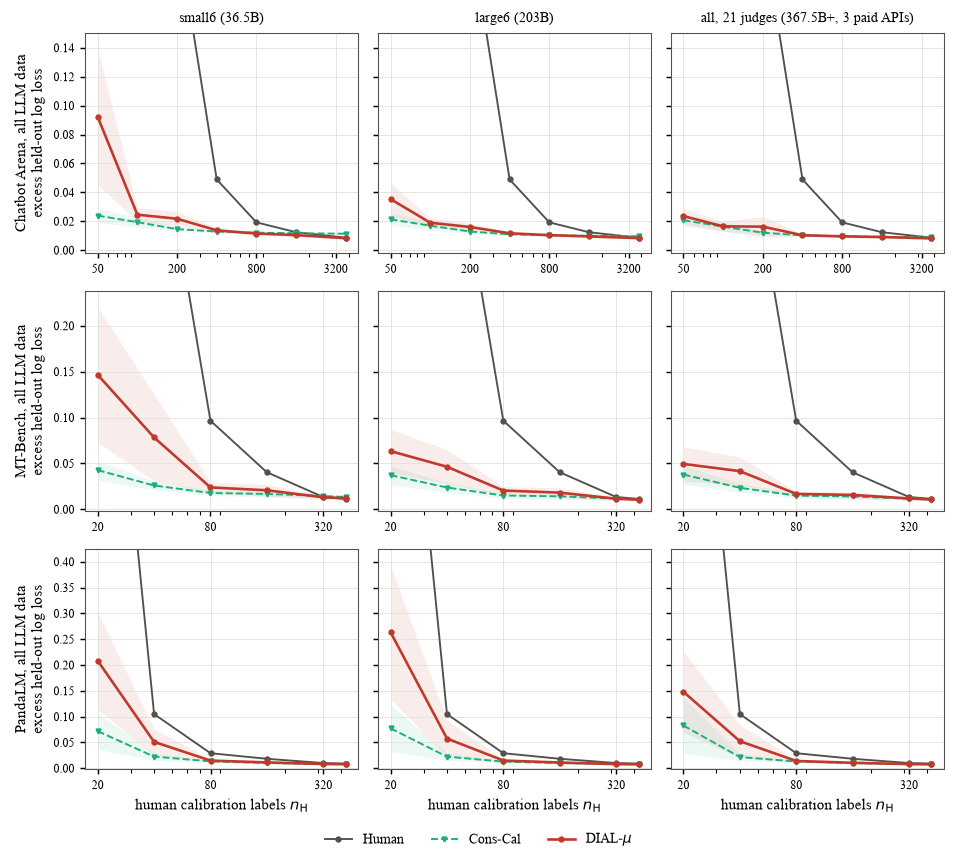

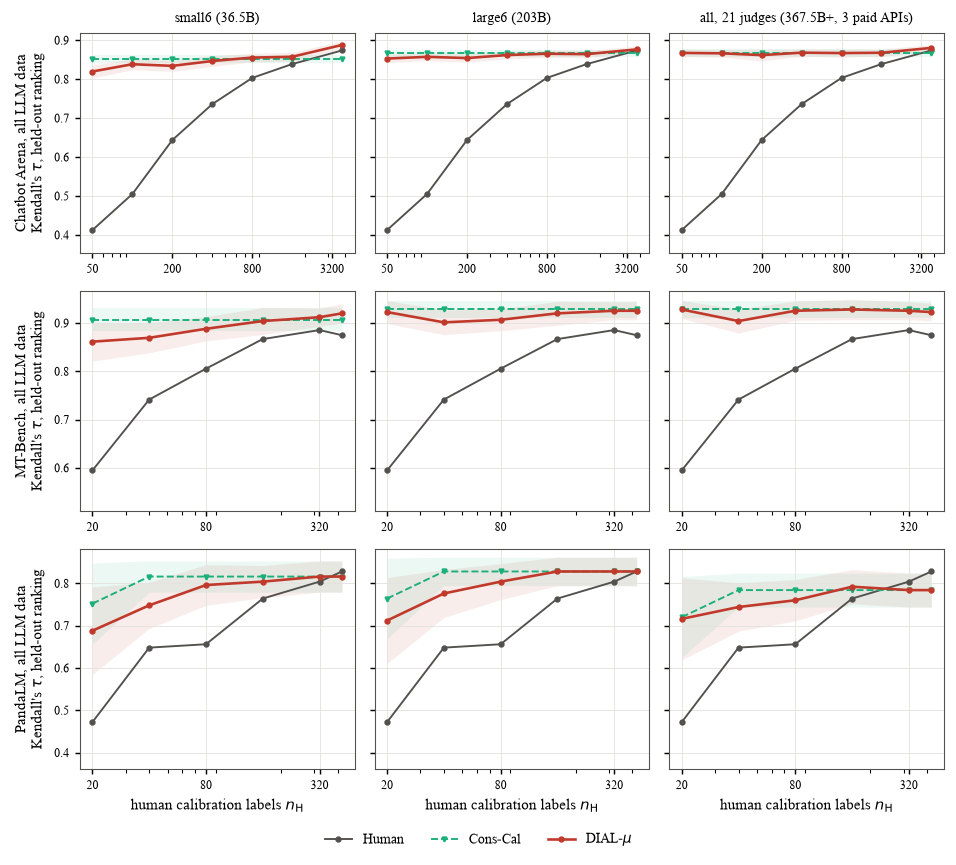

In [2]:
show("fig_small_panel")

## 2. LLM budget at a fixed human budget

The reverse constraint: an imprecise LLM-only direction limits Cons-Cal, while DIAL-$\mu$ can
re-estimate $\mu$ from the human comparisons.

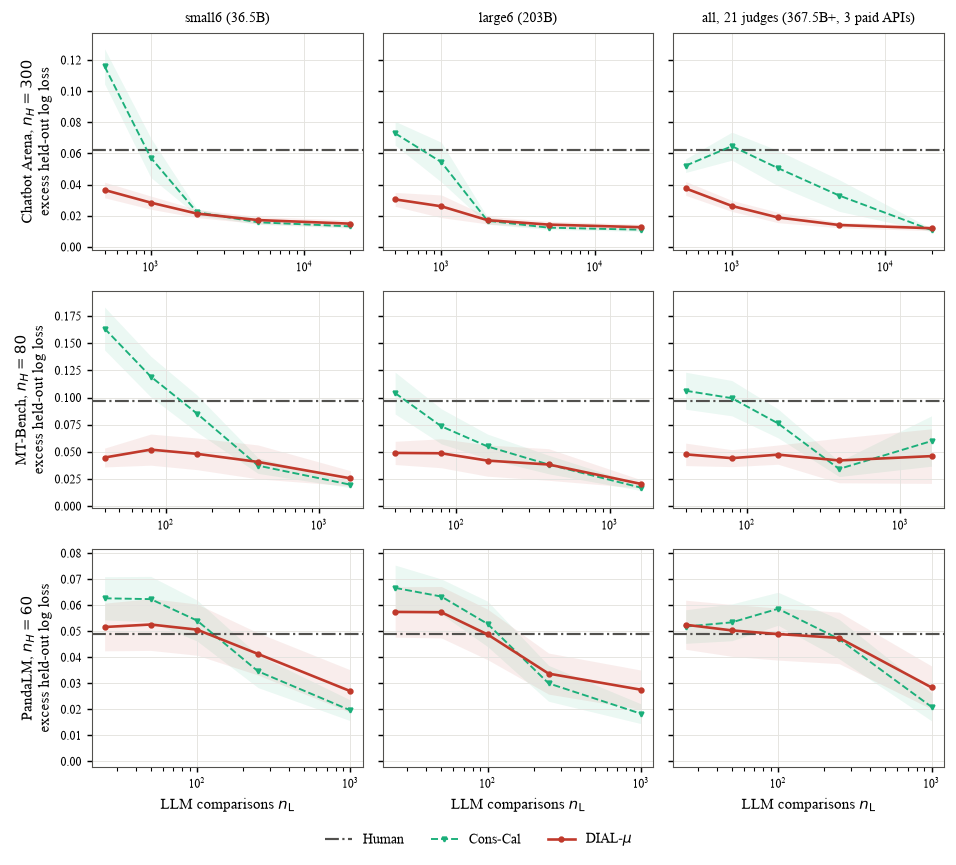

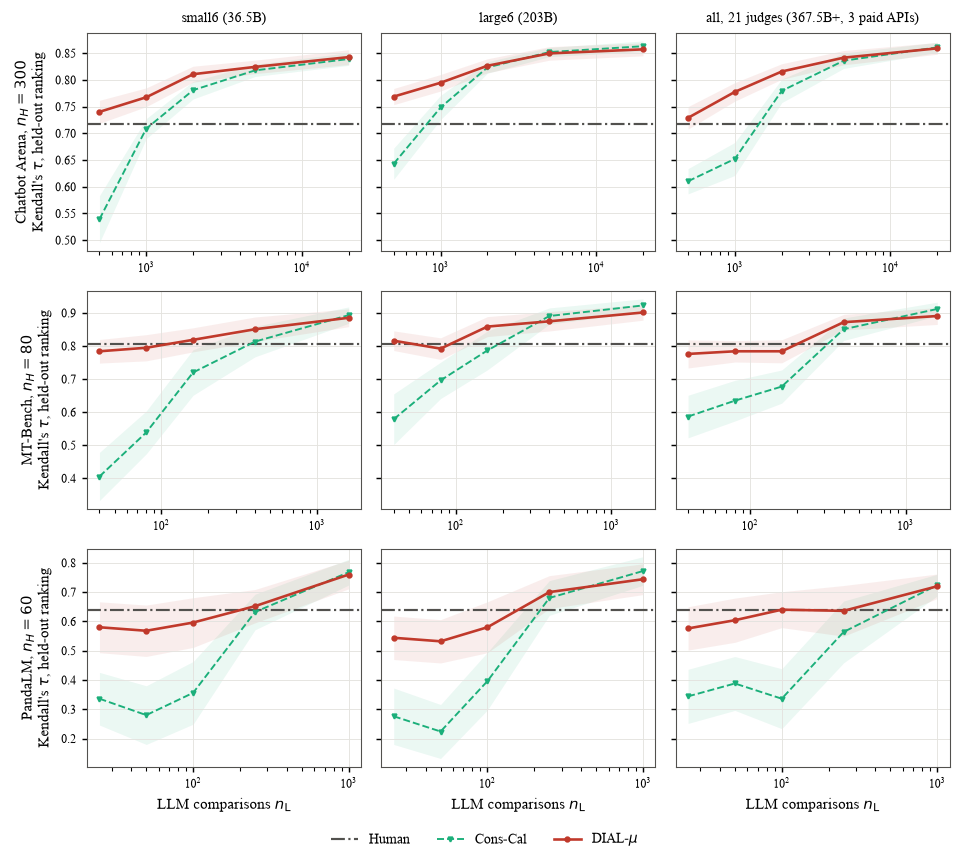

In [3]:
show("fig_small_panel_llmbudget")

## 3. Human budget at a fixed intermediate LLM budget

The middle LLM level of sweep 2, which exposes the crossover between keeping the LLM-only
consensus direction (Cons-Cal) and letting human comparisons update it (DIAL-$\mu$).

The contrast between the two metrics is sharpest here. On log loss the axis is set by
DIAL-$\mu$'s penalty at the smallest budget, so its eventual 2–6× advantage is compressed
into the baseline; on $\tau$ the plateau of Cons-Cal — which fits only the scalar $\alpha$
and so cannot improve past the consensus misalignment floor — is immediately visible.

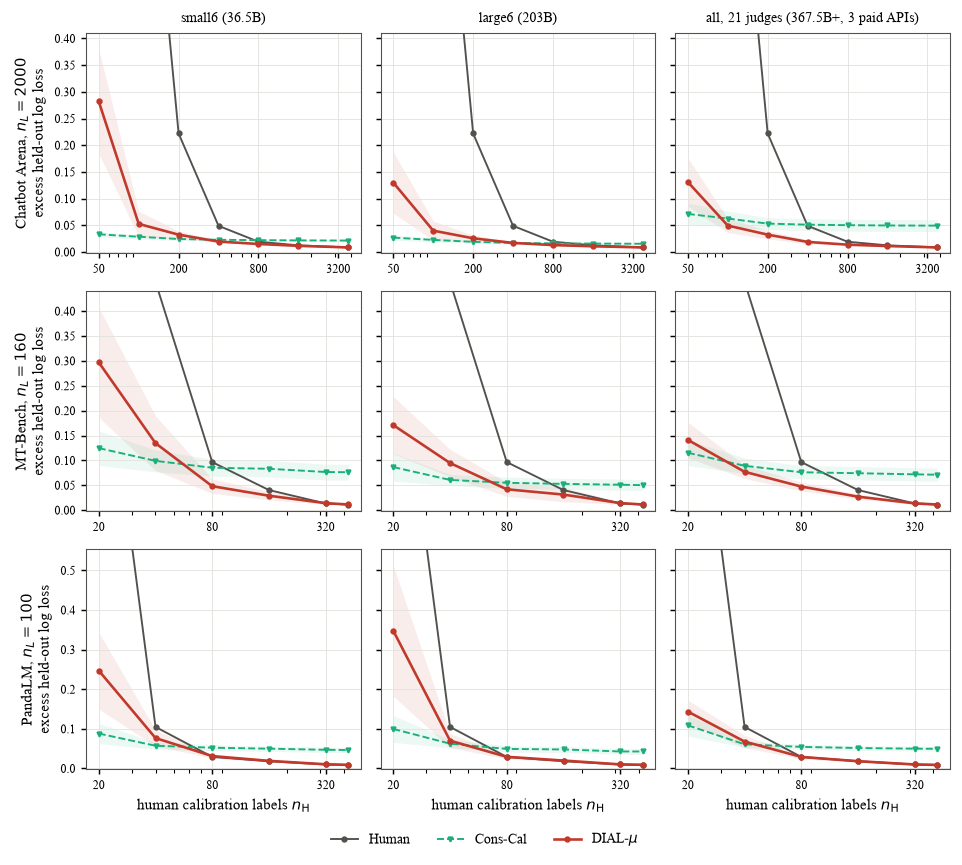

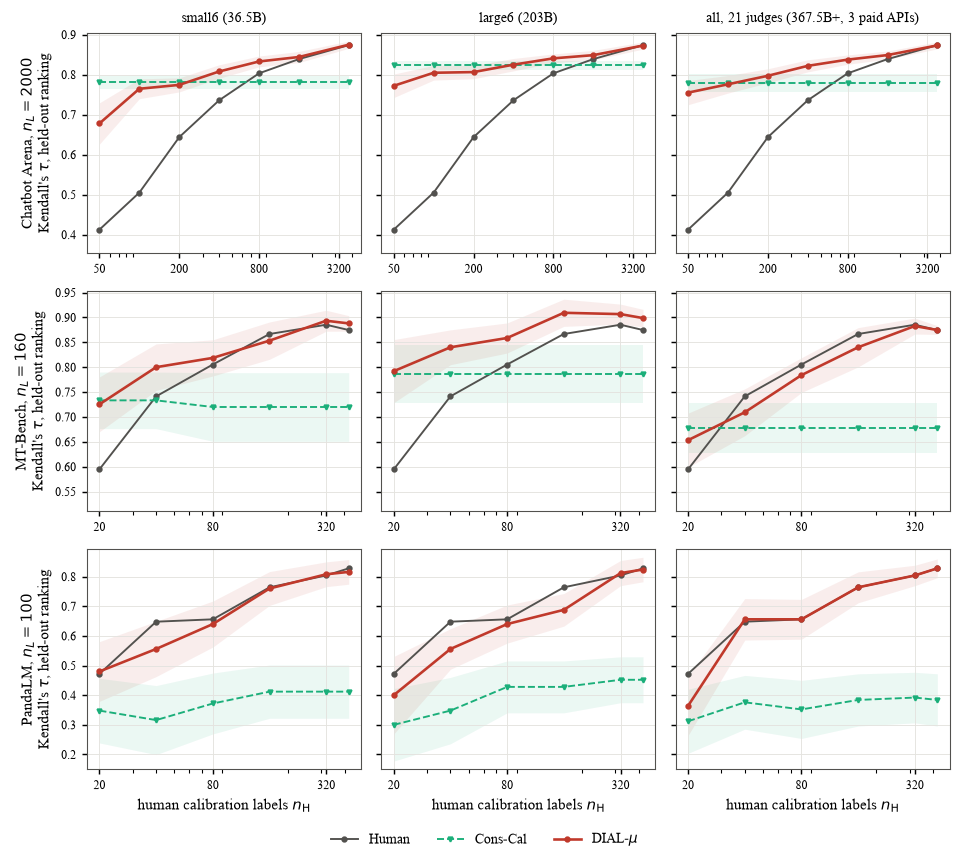

In [4]:
show("fig_intermediate_budget")

## Full-pool comparison in both metrics

DIAL-$\mu$ against Cons-Cal at the largest tested human budget: the log-loss ratio, the
$\tau$ gain, and whether each beats Cons-Cal by more than two paired Monte Carlo standard
errors.

In [5]:
rows = []
for (ds, panel), g in intermediate.groupby(["dataset", "panel"]):
    top = g[g.n_H == g.n_H.max()].set_index("method")
    rows.append(dict(dataset=ds, panel=panel, n_H=round(g.n_H.max()),
                     loss_cons=top.loc["consensus_cal", "excess"], loss_dial=top.loc["dial_mu", "excess"],
                     loss_ratio=top.loc["consensus_cal", "excess"] / top.loc["dial_mu", "excess"],
                     tau_cons=top.loc["consensus_cal", "tau"], tau_dial=top.loc["dial_mu", "tau"],
                     tau_gain=top.loc["dial_mu", "tau"] - top.loc["consensus_cal", "tau"],
                     loss_signif=bool(top.loc["dial_mu", "delta_vs_cons"]
                                      < -2 * top.loc["dial_mu", "paired_mcse"])))
pd.DataFrame(rows).round(4)

,dataset,panel,n_H,loss_cons,loss_dial,loss_ratio,tau_cons,tau_dial,tau_gain,loss_signif
0,arena_33k,all,3802,0.0493,0.0085,5.7976,0.7796,0.8731,0.0935,True
1,arena_33k,large6,3802,0.0154,0.0085,1.8125,0.8234,0.8726,0.0493,True
2,arena_33k,small6,3802,0.0214,0.0085,2.5153,0.7808,0.8747,0.0939,True
3,mt_bench,all,422,0.0712,0.0113,6.2858,0.6773,0.8747,0.1973,True
4,mt_bench,large6,422,0.0502,0.0114,4.4088,0.7867,0.8987,0.1120,True
5,mt_bench,small6,422,0.0762,0.0114,6.7032,0.7200,0.8880,0.1680,True
6,pandalm,all,421,0.0496,0.0089,5.5813,0.3840,0.8280,0.4440,True
7,pandalm,large6,421,0.0428,0.0092,4.6476,0.4520,0.8240,0.3720,True
8,pandalm,small6,421,0.0466,0.0090,5.1740,0.4120,0.8160,0.4040,True


## Descriptive crossover locations

The first tested human budget at which DIAL-$\mu$ beats Cons-Cal by more than two paired Monte
Carlo standard errors, and keeps doing so at every higher budget (appendix Table 3). A post hoc
summary of these curves, not a calibrated test or a switching rule for new data.

In [6]:
def crossover(frame):
    out = []
    for (ds, panel), g in frame.groupby(["dataset", "panel"]):
        g = g[g.method == "dial_mu"].sort_values("n_H").set_index("n_H")
        better = g.delta_vs_cons < -2 * g.paired_mcse
        first = next((n for n in better.index if better.loc[n:].all()), None)
        out.append(dict(dataset=ds, panel=panel, n_L=INTERMEDIATE_NL[ds], crossover_n_H=first))
    return pd.DataFrame(out)

crossover(intermediate).pivot(index="dataset", columns="panel", values="crossover_n_H")

panel,all,large6,small6
dataset,,,
arena_33k,200.0,800.0,400.0
mt_bench,80.0,160.0,80.0
pandalm,80.0,80.0,80.0
